# Superconducting Circuit Devices

Demos for the three device classes in **`devices.py`**:

| Class | Device |
|---|---|
| `Transmon` | Single transmon qubit in the charge basis |
| `TransmonResonator` | Transmon capacitively coupled to a microwave resonator |
| `TunableCouplerSystem` | Two transmons coupled via a flux-tunable SQUID coupler |

All energies in **GHz** with $\hbar = 1$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

from superqsim import Transmon, TransmonResonator, TunableCouplerSystem

plt.rcParams.update({"figure.dpi": 120, "font.size": 12})

---
## 1. Transmon

$$\hat{H} = 4E_C(\hat{n} - n_g)^2 - E_J\cos\hat{\varphi}$$

The charge basis truncated to $|n\rangle,\; n = -N\ldots N$ yields a tridiagonal Hamiltonian.
Charge-dispersion and EJ/Ec sweeps are methods on `Transmon`.

In [2]:
# Typical deep-transmon parameters
transmon = Transmon(Ec=0.2, EJ=30.0, ng=0.0, n_cutoff=15)

vals, vecs = transmon.get_eigenspectrum(num_levels=6)
omega_01 = transmon.transition_frequency(0, 1)
alpha    = transmon.anharmonicity()

print(f"EJ/Ec          : {transmon.EJ_over_Ec:.0f}")
print(f"Hilbert dim    : {transmon.dim}")
print(f"ω₀₁           : {omega_01:.4f} GHz")
print(f"Anharmonicity  : {alpha*1e3:.2f} MHz")
print()
print(f"{'Level':>6}  {'Energy (GHz)':>14}")
print("-" * 24)
for i, E in enumerate(vals):
    print(f"  |{i}⟩   {E:14.6f}")

EJ/Ec          : 150
Hilbert dim    : 31
ω₀₁           : 6.7219 GHz
Anharmonicity  : -215.02 MHz

 Level    Energy (GHz)
------------------------
  |0⟩         0.000000
  |1⟩         6.721940
  |2⟩        13.228863
  |3⟩        19.508665
  |4⟩        25.546657
  |5⟩        31.324519


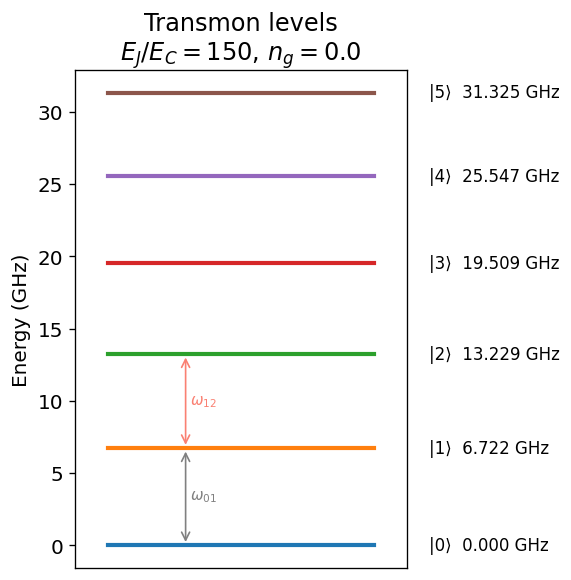

In [3]:
# Energy-level diagram with 01 and 12 transitions labelled
fig, ax = plt.subplots(figsize=(5, 5))
for i, E in enumerate(vals):
    ax.axhline(E, xmin=0.1, xmax=0.9, lw=2.5, color=f"C{i}")
    ax.text(1.6, E, f"|{i}⟩  {E:.3f} GHz", va="center", fontsize=10)

ax.annotate("", xy=(0.5, vals[1]), xytext=(0.5, vals[0]),arrowprops=dict(arrowstyle="<->", color="gray"))
ax.text(0.52, (vals[0] + vals[1]) / 2, r"$\omega_{01}$", fontsize=9, color="gray", va="center")

ax.annotate("", xy=(0.5, vals[2]), xytext=(0.5, vals[1]),arrowprops=dict(arrowstyle="<->", color="salmon"))
ax.text(0.52, (vals[1] + vals[2]) / 2, r"$\omega_{12}$", fontsize=9, color="salmon", va="center")

ax.set_xlim(0, 1.5)
ax.set_ylabel("Energy (GHz)")
ax.set_title(f"Transmon levels\n$E_J/E_C={transmon.EJ_over_Ec:.0f}$, $n_g={transmon.ng}$")
ax.set_xticks([])
plt.tight_layout()
plt.show()

### 1a.  Charge-dispersion sweep

Sweeping $n_g$ shows the energy bands.  The **charge dispersion**
$\epsilon_m = \max_{n_g}E_m - \min_{n_g}E_m$ decreases exponentially with
$\sqrt{E_J/E_C}$ — the defining advantage of the transmon regime.

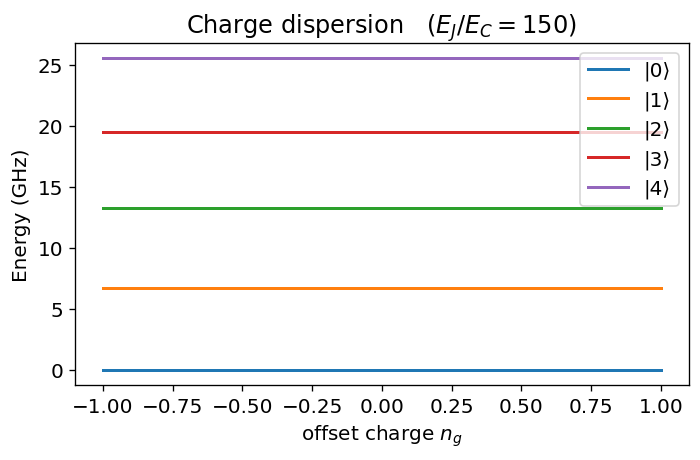

Peak-to-peak charge dispersion:
  |0⟩ : 0.0000 MHz
  |1⟩ : 0.0000 MHz
  |2⟩ : 0.0000 MHz
  |3⟩ : 0.0000 MHz
  |4⟩ : 0.0009 MHz


In [4]:
ng_vals = np.linspace(-1.0, 1.0, 300)
energies = transmon.charge_dispersion_sweep(ng_vals, num_levels=5)

fig, ax = plt.subplots(figsize=(6, 4))
for level in range(energies.shape[1]):
    ax.plot(ng_vals, energies[:, level], color=f"C{level}", lw=1.8, label=f"|{level}⟩")
ax.set_xlabel("offset charge $n_g$")
ax.set_ylabel("Energy (GHz)")
ax.set_title(f"Charge dispersion   ($E_J/E_C = {transmon.EJ_over_Ec:.0f}$)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

disp = energies.max(axis=0) - energies.min(axis=0)
print("Peak-to-peak charge dispersion:")
for i, d in enumerate(disp):
    print(f"  |{i}⟩ : {d*1e3:.4f} MHz")

### 1b.  EJ/Ec crossover sweep

As $E_J/E_C$ grows the qubit frequency stabilises and the anharmonicity saturates at $-E_C$.

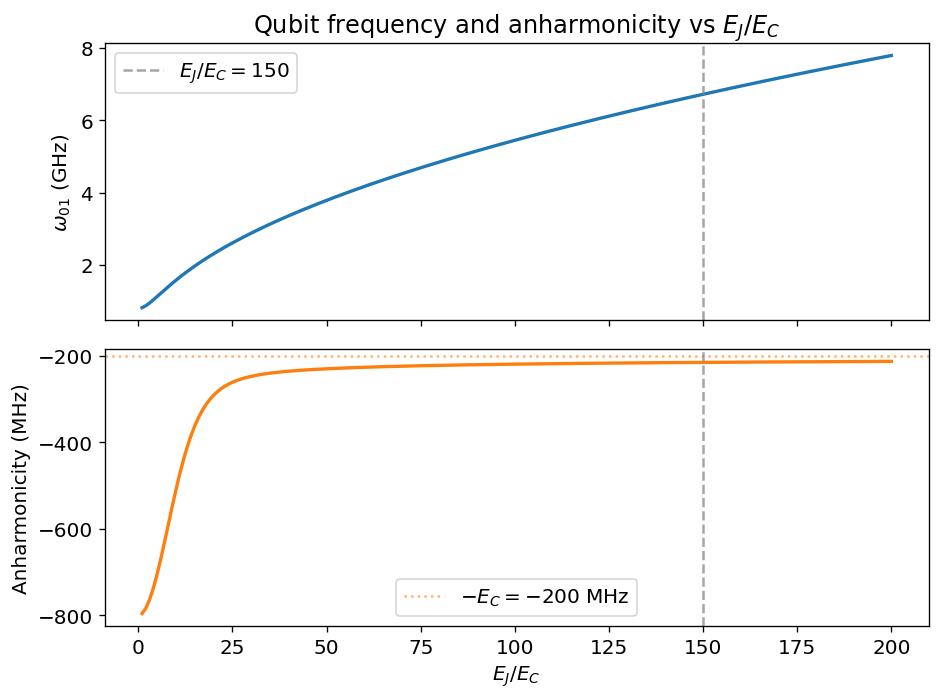

In [5]:
ratios = np.linspace(1, 200, 200)
freqs, anharmon = transmon.ej_ec_sweep(ratios)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.plot(ratios, freqs, color="C0", lw=2)
ax1.axvline(transmon.EJ_over_Ec, ls="--", color="gray", alpha=0.7, label=f"$E_J/E_C={transmon.EJ_over_Ec:.0f}$")
ax1.set_ylabel("$\\omega_{01}$ (GHz)")
ax1.set_title("Qubit frequency and anharmonicity vs $E_J/E_C$")
ax1.legend()

ax2.plot(ratios, anharmon * 1e3, color="C1", lw=2)
ax2.axhline(-transmon.Ec * 1e3, ls=":", color="C1", alpha=0.6, label=f"$-E_C = {-transmon.Ec*1e3:.0f}$ MHz")
ax2.axvline(transmon.EJ_over_Ec, ls="--", color="gray", alpha=0.7)
ax2.set_xlabel("$E_J/E_C$")
ax2.set_ylabel("Anharmonicity (MHz)")
ax2.legend()

plt.tight_layout()
plt.show()

---
## 2.  TransmonResonator

A transmon qubit coupled to a single-mode microwave resonator:

$$H = H_t \otimes I_r + I_t \otimes \omega_r a^\dagger a + g\,\hat{n}_t \otimes (a + a^\dagger)$$

Key regimes:
- **Resonant** ($\omega_r \approx \omega_{01}$): vacuum-Rabi splitting $\approx 2g|\langle 0|\hat{n}|1\rangle|$.
- **Dispersive** ($|\omega_{01} - \omega_r| \gg g$): qubit-state-dependent resonator shift $\chi$.

In [17]:
# Dispersive regime: resonator far above transmon frequency
dev = TransmonResonator(
    Ec=0.2, EJ=10.0,          # same transmon
    omega_r=6.0, g=0.05,        # resonator at 6 GHz, coupling 100 MHz
    ng=0.0, n_cutoff=15, n_fock=10,
)

omega_01 = dev.transmon.transition_frequency(0, 1)
chi = dev.dispersive_shift

print(f"Transmon ω₀₁   : {omega_01:.4f} GHz")
print(f"Resonator ω_r  : {dev.omega_r:.4f} GHz")
print(f"Detuning Δ     : {omega_01 - dev.omega_r:.4f} GHz")
print(f"Coupling g     : {dev.g*1e3:.0f} MHz")
print(f"Dispersive χ   : {chi*1e3:.4f} MHz")
print(f"Composite dim  : {dev.dim}")

Transmon ω₀₁   : 3.7884 GHz
Resonator ω_r  : 6.0000 GHz
Detuning Δ     : -2.2116 GHz
Coupling g     : 50 MHz
Dispersive χ   : -0.1064 MHz
Composite dim  : 310


### 2a.  Vacuum-Rabi avoided crossing

Sweep $\omega_r$ through the transmon frequency.  In the uncoupled limit the first two excited
eigenvalues simply cross; the coupling $g$ opens a gap — the **vacuum-Rabi splitting**.

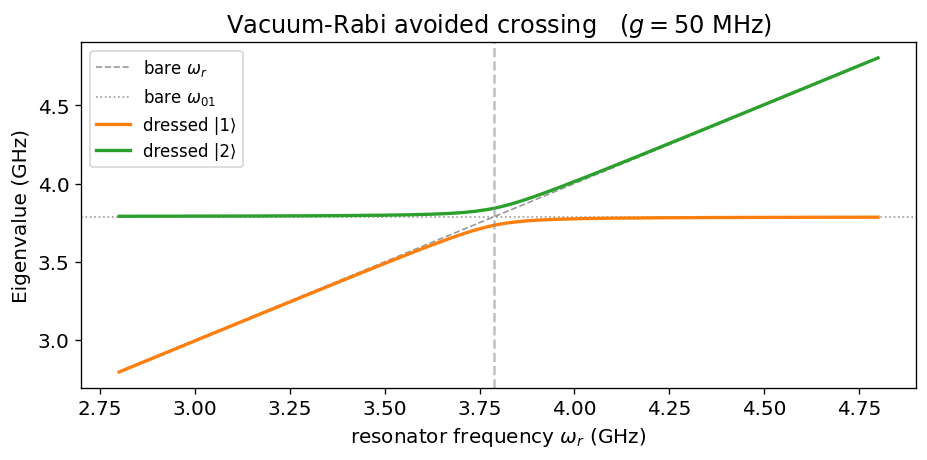

Vacuum-Rabi splitting at resonance: 108.90 MHz


In [18]:
wr_vals = np.linspace(2.8, 4.8, 150)
spectrum = dev.resonator_frequency_sweep(wr_vals, num_levels=4)

fig, ax = plt.subplots(figsize=(8, 4))

# Bare (uncoupled) energies for reference
ax.plot(wr_vals, wr_vals, "k--", lw=1, alpha=0.4, label=r"bare $\omega_r$")
ax.axhline(omega_01, color="k", ls=":", lw=1, alpha=0.4, label=r"bare $\omega_{01}$")

# Dressed eigenvalues
for lvl in [1, 2]:
    ax.plot(wr_vals, spectrum[:, lvl], color=f"C{lvl}", lw=2, label=f"dressed |{lvl}⟩")

ax.axvline(omega_01, ls="--", color="gray", alpha=0.5)
ax.set_xlabel("resonator frequency $\\omega_r$ (GHz)")
ax.set_ylabel("Eigenvalue (GHz)")
ax.set_title(f"Vacuum-Rabi avoided crossing   ($g = {dev.g*1e3:.0f}$ MHz)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Splitting at resonance
idx = np.argmin(np.abs(wr_vals - omega_01))
splitting = spectrum[idx, 2] - spectrum[idx, 1]
print(f"Vacuum-Rabi splitting at resonance: {splitting*1e3:.2f} MHz")

### 2b.  Dispersive shift vs detuning

In the dispersive limit $|\Delta| \gg g$, the resonator frequency shifts by $\pm\chi$
depending on the qubit state — the basis of dispersive readout.

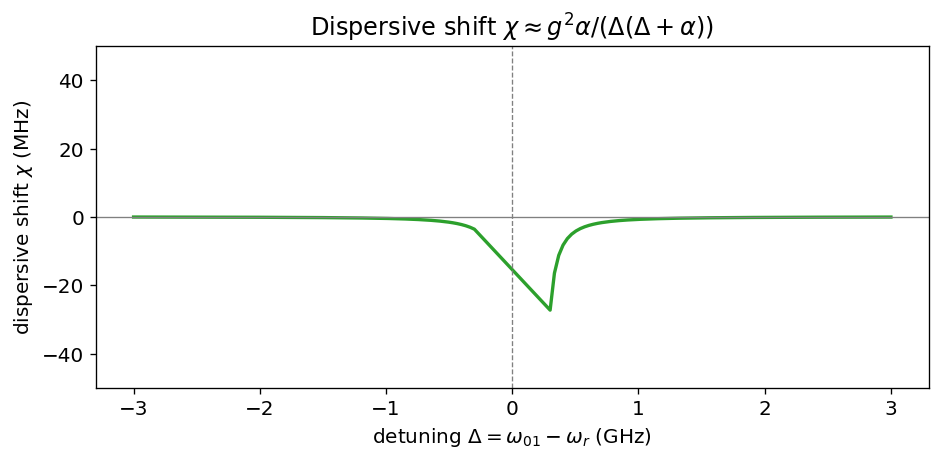

In [19]:
# Sweep omega_r far from resonance on both sides
detunings = np.concatenate([
    np.linspace(-3.0, -0.3, 80),
    np.linspace( 0.3,  3.0, 80),
])
wr_sweep = omega_01 - detunings  # omega_r = omega_01 - Delta

chi_vals = []
saved_wr = dev.omega_r
for wr in wr_sweep:
    dev.omega_r = wr
    chi_vals.append(dev.dispersive_shift)
dev.omega_r = saved_wr
chi_vals = np.array(chi_vals)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(detunings, chi_vals * 1e3, color="C2", lw=2)
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel(r"detuning $\Delta = \omega_{01} - \omega_r$ (GHz)")
ax.set_ylabel(r"dispersive shift $\chi$ (MHz)")
ax.set_title(r"Dispersive shift $\chi \approx g^2\alpha / (\Delta(\Delta+\alpha))$")
ax.set_ylim(-50, 50)
plt.tight_layout()
plt.show()

### 2c.  Jaynes-Cummings Hamiltonians — lab, rotating-RWA, rotating (no RWA)

`build_hamiltonian` now accepts a `frame` keyword selecting one of three descriptions:

| `frame` | Returns | Description |
|---|---|---|
| `'lab'` | `qt.Qobj` | Full transmon ⊗ Fock, no approximations; dim = $d_t \times n_{\rm Fock}$ |
| `'rotating_rwa'` | `qt.Qobj` | JC model in rotating frame + RWA; time-independent; dim = $2 \times n_{\rm Fock}$ |
| `'rotating'` | `list` | Rotating frame **without** RWA; qutip time-dependent list for `sesolve` / `mesolve` |

The transmon is truncated to a **two-level qubit** (frequency $\omega_q = \omega_{01}$) with
effective coupling $g_{\rm eff} = g\,|\langle 1|\hat{n}|0\rangle|$.  The drive frequency
$\omega_d$ (keyword `omega_d`, default $\omega_r$) sets the rotating frame:

$$H_{\rm JC}^{\rm RWA} = \frac{\Delta_q}{2}\sigma_z + \Delta_r\,a^\dagger a + g_{\rm eff}(\sigma_+ a + \sigma_- a^\dagger),\quad \Delta_q = \omega_q - \omega_d,\;\Delta_r = \omega_r - \omega_d$$

$$H(t) = H_{\rm JC}^{\rm RWA} + g_{\rm eff}\!\left(\sigma_+ a^\dagger\,e^{+2i\omega_d t} + \sigma_- a\,e^{-2i\omega_d t}\right)\qquad\text{(non-RWA: counter-rotating terms)}$$

In [20]:
omega_q  = dev.transmon.transition_frequency(0, 1)   # same as omega_01
g_eff_jc = dev._jc_coupling()

print(f"Qubit  ω_q           : {omega_q:.4f} GHz")
print(f"Resonator ω_r        : {dev.omega_r:.4f} GHz")
print(f"Detuning Δ           : {omega_q - dev.omega_r:.4f} GHz  (dispersive regime)")
print(f"Bare coupling g      : {dev.g * 1e3:.1f} MHz")
print(f"JC coupling g_eff    : {g_eff_jc * 1e3:.3f} MHz   (= g |⟨1|n̂|0⟩|)")

# Build all three Hamiltonians; ω_d defaults to ω_r
H_lab = dev.build_hamiltonian(frame="lab")
H_rwa = dev.build_hamiltonian(frame="rotating_rwa")
H_rot = dev.build_hamiltonian(frame="rotating")

print(f"\n{'frame':<16}  {'type':<10}  shape")
print("-" * 48)
print(f"{'lab':<16}  {'Qobj':<10}  {H_lab.shape}  (full transmon × Fock)")
print(f"{'rotating_rwa':<16}  {'Qobj':<10}  {H_rwa.shape}  (2-level qubit × Fock)")
print(f"{'rotating':<16}  {'list[3]':<10}  H0={H_rot[0].shape}, [H_cr, e^{{+2iω_d t}}], [H_cr†, e^{{-2iω_d t}}]")
print(f"\nH_rwa Hermitian        : {np.allclose(H_rwa.full(), H_rwa.full().conj().T)}")
print(f"H_rot counter-rotating : H_cr = (H_cr†)†   {np.allclose(H_rot[1][0].full(), H_rot[2][0].dag().full())}")

Qubit  ω_q           : 3.7884 GHz
Resonator ω_r        : 6.0000 GHz
Detuning Δ           : -2.2116 GHz  (dispersive regime)
Bare coupling g      : 50.0 MHz
JC coupling g_eff    : 54.390 MHz   (= g |⟨1|n̂|0⟩|)

frame             type        shape
------------------------------------------------
lab               Qobj        (310, 310)  (full transmon × Fock)
rotating_rwa      Qobj        (20, 20)  (2-level qubit × Fock)
rotating          list[3]     H0=(20, 20), [H_cr, e^{+2iω_d t}], [H_cr†, e^{-2iω_d t}]

H_rwa Hermitian        : True
H_rot counter-rotating : H_cr = (H_cr†)†   True


### 2c-i.  JC dressed states vs qubit-resonator detuning

In the rotating frame with $\Delta_r = 0$ (frame locked to the resonator), the $N=1$ excitation
manifold $\{|e,0\rangle,\,|g,1\rangle\}$ has bare energies $\pm\Delta/2$ that cross at resonance
$\Delta = \omega_q - \omega_r = 0$.  The coupling $g_{\rm eff}$ hybridises them into dressed states
at $\pm\sqrt{\Delta^2/4 + g_{\rm eff}^2}$, opening a gap $2g_{\rm eff}$ — the **vacuum-Rabi splitting** seen
from section 2a.

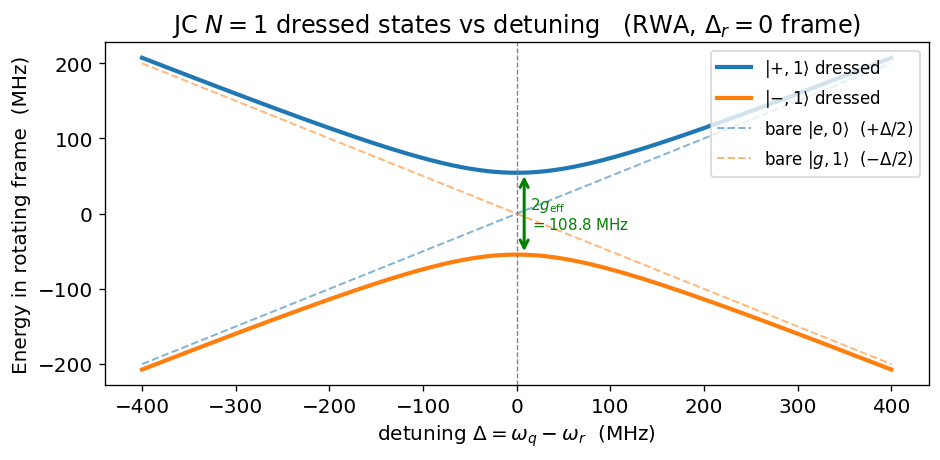

Vacuum-Rabi gap  2g_eff = 108.780 MHz  (analytical, from N=1 block)


In [21]:
# Analytical N=1 dressed-state energies in the Δ_r = 0 rotating frame
# Bare states:  |e,0⟩ at +Δ/2,  |g,1⟩ at −Δ/2  (Δ_r = 0 → photon costs no energy)
# Dressed states:  ±√(Δ²/4 + g_eff²)   from diagonalising the 2×2 N=1 block

delta = np.linspace(-0.4, 0.4, 400)     # Δ = ω_q − ω_r  (GHz)
E_plus  =  np.sqrt(delta**2 / 4 + g_eff_jc**2)
E_minus = -np.sqrt(delta**2 / 4 + g_eff_jc**2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(delta * 1e3, E_plus  * 1e3, "C0", lw=2.5, label=r"$|{+,1}\rangle$ dressed")
ax.plot(delta * 1e3, E_minus * 1e3, "C1", lw=2.5, label=r"$|{-,1}\rangle$ dressed")
ax.plot(delta * 1e3,  delta / 2 * 1e3, "C0--", lw=1.2, alpha=0.55, label=r"bare $|e,0\rangle$  ($+\Delta/2$)")
ax.plot(delta * 1e3, -delta / 2 * 1e3, "C1--", lw=1.2, alpha=0.55, label=r"bare $|g,1\rangle$  ($-\Delta/2$)")
ax.axvline(0, color="gray", ls="--", lw=0.8)

# Annotate the vacuum-Rabi gap at resonance
ax.annotate("", xy=(8, g_eff_jc * 1e3), xytext=(8, -g_eff_jc * 1e3),
            arrowprops=dict(arrowstyle="<->", color="green", lw=1.8))
ax.text(14, 0, f"$2g_{{\\rm eff}}$\n$= {2*g_eff_jc*1e3:.1f}$ MHz",
        color="green", va="center", fontsize=9)

ax.set_xlabel(r"detuning $\Delta = \omega_q - \omega_r$  (MHz)")
ax.set_ylabel("Energy in rotating frame  (MHz)")
ax.set_title(r"JC $N=1$ dressed states vs detuning   (RWA, $\Delta_r = 0$ frame)")
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

print(f"Vacuum-Rabi gap  2g_eff = {2*g_eff_jc*1e3:.3f} MHz  (analytical, from N=1 block)")

### 2c-ii.  Vacuum Rabi oscillations — RWA vs. rotating frame (no RWA)

Start in $|e,0\rangle$ (qubit excited, cavity vacuum) with the resonator on resonance ($\omega_r = \omega_q$, $\Delta = 0$) and integrate the Schrödinger equation with `qt.sesolve`.

- **`frame='rotating_rwa'`** — time-independent $H_{\rm JC}$; exact within the two-level + RWA approximation:
$$P_e(t) = \cos^2(g_{\rm eff}\,t), \qquad \langle n_r\rangle(t) = \sin^2(g_{\rm eff}\,t)$$
- **`frame='rotating'`** — `sesolve` receives the qutip time-dependent list directly; the counter-rotating terms at $2\omega_d$ add **Bloch–Siegert micro-oscillations** of amplitude $\sim(g_{\rm eff}/2\omega_d)^2$ on top of the Rabi envelope.

ω_q = ω_r = 3.7884 GHz   (resonant, Δ = 0)
g_eff     = 108.780 MHz
T_Rabi    = 57.76  GHz⁻¹
Counter-rotating scale  g_eff/(2ω_d) = 14.36 × 10⁻³


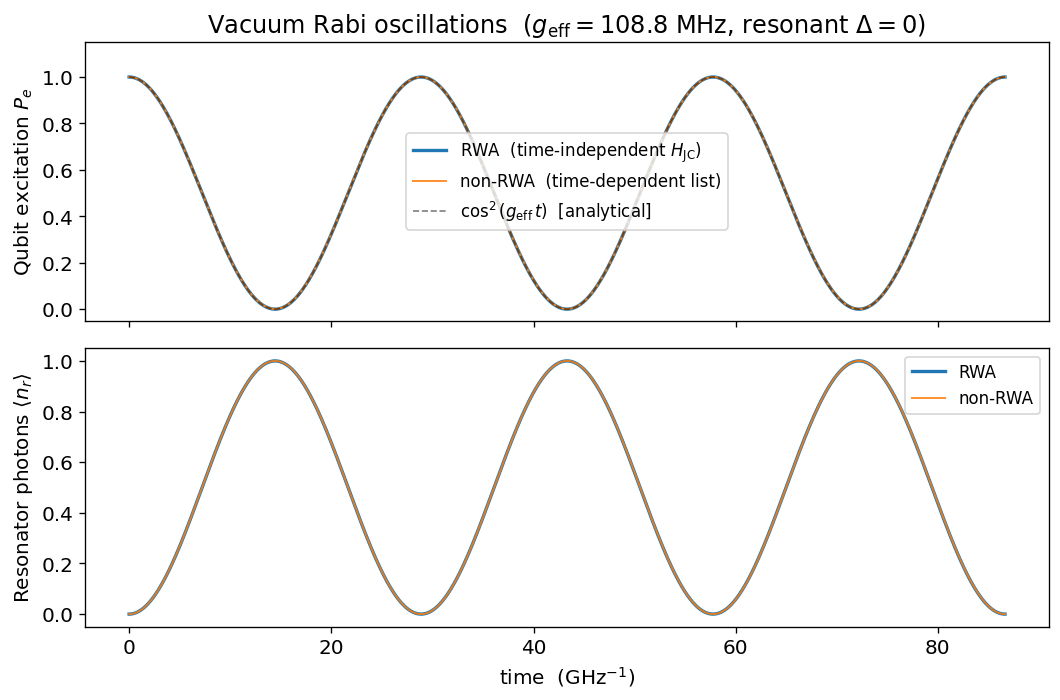

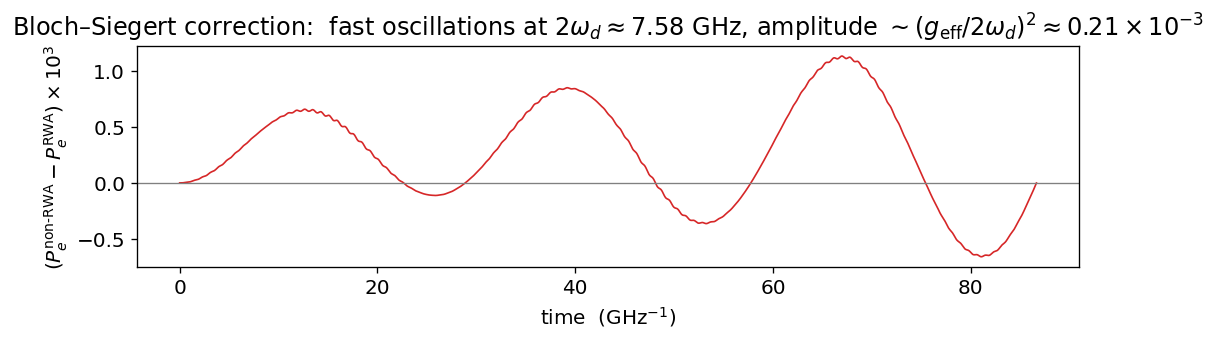

In [22]:
# Resonant device: ω_r = ω_q so Δ = 0 (use g=0.1 for a visible Rabi frequency)
dev_res      = TransmonResonator(Ec=0.2, EJ=10.0, omega_r=omega_01, g=0.1, n_fock=12)
g_eff_res    = dev_res._jc_coupling()
T_rabi       = 2 * np.pi / g_eff_res       # full Rabi period (GHz⁻¹)

print(f"ω_q = ω_r = {omega_01:.4f} GHz   (resonant, Δ = 0)")
print(f"g_eff     = {g_eff_res * 1e3:.3f} MHz")
print(f"T_Rabi    = {T_rabi:.2f}  GHz⁻¹")
print(f"Counter-rotating scale  g_eff/(2ω_d) = {g_eff_res/(2*omega_01)*1e3:.2f} × 10⁻³")

omega_d_res = omega_01
H_rwa_res   = dev_res.build_hamiltonian(frame="rotating_rwa", omega_d=omega_d_res)
H_rot_res   = dev_res.build_hamiltonian(frame="rotating",     omega_d=omega_d_res)

n_f   = dev_res.n_fock
psi0  = qt.tensor(qt.basis(2, 0), qt.basis(n_f, 0))   # |e, 0⟩
sz_op = qt.tensor(qt.sigmaz(), qt.qeye(n_f))
nr_op = qt.tensor(qt.qeye(2),  qt.num(n_f))

# 1.5 Rabi cycles; dt ≈ 0.06 GHz⁻¹ gives ~14 pts per 2ω_d fast-oscillation period
tlist = np.linspace(0, 1.5 * T_rabi, 2000)

res_rwa = qt.sesolve(H_rwa_res, psi0, tlist, e_ops=[sz_op, nr_op])
res_rot  = qt.sesolve(H_rot_res,  psi0, tlist, e_ops=[sz_op, nr_op])

P_e_rwa = (1 + np.array(res_rwa.expect[0])) / 2
P_e_rot  = (1 + np.array(res_rot.expect[0]))  / 2
nr_rwa   = np.array(res_rwa.expect[1])
nr_rot   = np.array(res_rot.expect[1])

# --- Rabi oscillations: RWA vs non-RWA ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.plot(tlist, P_e_rwa, "C0",  lw=2,   label="RWA  (time-independent $H_{\\rm JC}$)")
ax1.plot(tlist, P_e_rot,  "C1",  lw=1.2, alpha=0.85, label="non-RWA  (time-dependent list)")
ax1.plot(tlist, np.cos(g_eff_res * tlist)**2, "k--", lw=1, alpha=0.5,
         label=r"$\cos^2(g_{\rm eff}\,t)$  [analytical]")
ax1.set_ylabel("Qubit excitation $P_e$")
ax1.set_title(fr"Vacuum Rabi oscillations  "
              fr"($g_{{\rm eff}} = {g_eff_res*1e3:.1f}$ MHz, resonant $\Delta = 0$)")
ax1.legend(fontsize=10)
ax1.set_ylim(-0.05, 1.15)

ax2.plot(tlist, nr_rwa, "C0", lw=2,   label="RWA")
ax2.plot(tlist, nr_rot,  "C1", lw=1.2, alpha=0.85, label="non-RWA")
ax2.set_ylabel(r"Resonator photons $\langle n_r \rangle$")
ax2.set_xlabel(r"time  (GHz$^{-1}$)")
ax2.legend(fontsize=10)
plt.tight_layout()
plt.show()

# --- Bloch–Siegert difference: counter-rotating correction ---
fig2, ax = plt.subplots(figsize=(9, 3))
ax.plot(tlist, (P_e_rot - P_e_rwa) * 1e3, color="C3", lw=1)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel(r"time  (GHz$^{-1}$)")
ax.set_ylabel(r"$(P_e^{\rm non\text{-}RWA} - P_e^{\rm RWA})\times 10^3$")
ax.set_title(fr"Bloch–Siegert correction:  fast oscillations at $2\omega_d \approx {2*omega_d_res:.2f}$ GHz, "
             fr"amplitude $\sim (g_{{\rm eff}}/2\omega_d)^2 \approx {(g_eff_res/(2*omega_d_res))**2*1e3:.2f}\times 10^{{-3}}$")
plt.tight_layout()
plt.show()

---
## 3.  TunableCouplerSystem

Two transmons (A, B) coupled via a SQUID coupler (C).  An external flux $\Phi$ tunes the
coupler Josephson energy and thereby the effective inter-qubit coupling:

$$E_J^{(C)}(\Phi) = E_J^{\max} \left|\cos\left(\frac{\pi\Phi}{\Phi_0}\right)\right|$$

The composite Hamiltonian is assembled in the dressed single-qubit eigenbasis.  The
Schrieffer–Wolff estimate of the effective coupling is:

$$g_{\rm eff}(\Phi) = \frac{g_{AC}\,g_{BC}}{2}\left(\frac{1}{\Delta_{AC}} + \frac{1}{\Delta_{BC}}\right),
\qquad \Delta_{iC} = \omega_i - \omega_C(\Phi)$$

Tuning $\omega_C$ through the qubit frequencies flips the sign of $g_{\rm eff}$.

In [9]:
system = TunableCouplerSystem(
    Ec_A=0.20, EJ_A=10.0,          # qubit A: ω_A ≈ 3.79 GHz
    Ec_B=0.20, EJ_B=9.5,           # qubit B: ω_B ≈ 3.69 GHz (slightly detuned)
    Ec_C=0.30, EJ_max_C=18.0,      # coupler at Φ=0: ω_C ≈ 6.3 GHz (above qubits)
    g_AC=0.10, g_BC=0.10,          # 100 MHz capacitive couplings
    n_cutoff=15,
    n_levels_A=3, n_levels_B=3, n_levels_C=3,
)

omega_A = system.transmon_A.transition_frequency(0, 1)
omega_B = system.transmon_B.transition_frequency(0, 1)
omega_C0 = system._make_coupler(0.0).transition_frequency(0, 1)

print(f"Qubit A  ω₀₁ : {omega_A:.4f} GHz")
print(f"Qubit B  ω₀₁ : {omega_B:.4f} GHz")
print(f"Coupler ω_C  : {omega_C0:.4f} GHz  (at Φ/Φ₀ = 0)")
print(f"g_AC / g_BC  : {system.g_AC*1e3:.0f} / {system.g_BC*1e3:.0f} MHz")

Qubit A  ω₀₁ : 3.7884 GHz
Qubit B  ω₀₁ : 3.6867 GHz
Coupler ω_C  : 6.2570 GHz  (at Φ/Φ₀ = 0)
g_AC / g_BC  : 100 / 100 MHz


### 3a  Coupler frequency vs flux

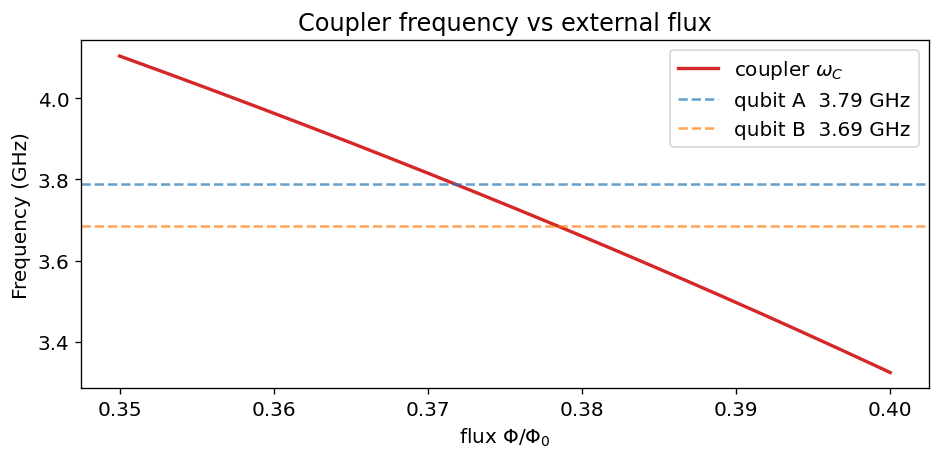

In [13]:
flux_vals = np.linspace(0.35, 0.4, 200)
omega_C_vals = np.array([
    system._make_coupler(f).transition_frequency(0, 1) for f in flux_vals
])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(flux_vals, omega_C_vals, color="C3", lw=2, label="coupler $\\omega_C$")
ax.axhline(omega_A, ls="--", color="C0", alpha=0.7, label=f"qubit A  {omega_A:.2f} GHz")
ax.axhline(omega_B, ls="--", color="C1", alpha=0.7, label=f"qubit B  {omega_B:.2f} GHz")
ax.set_xlabel(r"flux $\Phi/\Phi_0$")
ax.set_ylabel("Frequency (GHz)")
ax.set_title("Coupler frequency vs external flux")
ax.legend()
plt.tight_layout()
plt.show()

### 3b  Effective coupling vs flux (Schrieffer–Wolff)

The effective coupling $g_{\rm eff}$ flips sign as the coupler crosses qubit resonance.
In a full device with a residual direct coupling $g_{AB}$, this zero crossing is used
to switch the interaction off.

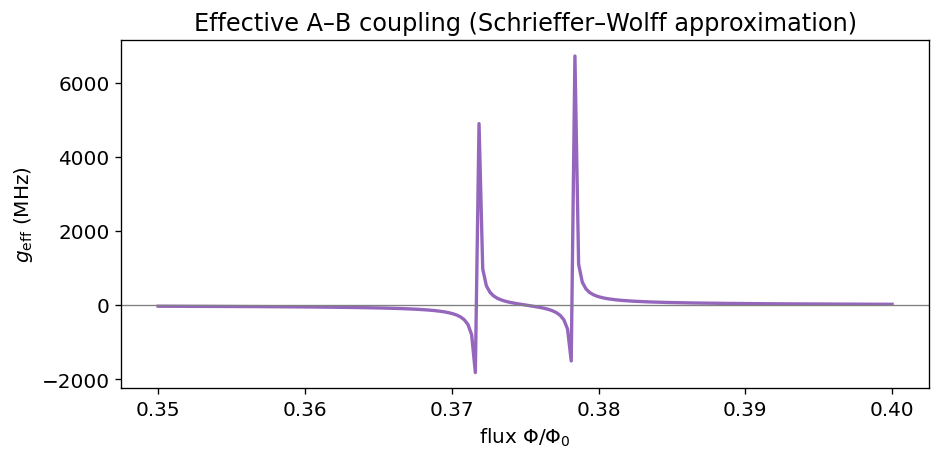

g_eff at Φ/Φ₀ = 0   : -27.84 MHz
g_eff at Φ/Φ₀ = 0.4 : 24.61 MHz


In [14]:
g_eff = system.effective_coupling(flux_vals)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(flux_vals, g_eff * 1e3, color="C4", lw=2)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel(r"flux $\Phi/\Phi_0$")
ax.set_ylabel("$g_{\\rm eff}$ (MHz)")
ax.set_title("Effective A–B coupling (Schrieffer–Wolff approximation)")
plt.tight_layout()
plt.show()

valid = ~np.isnan(g_eff)
print(f"g_eff at Φ/Φ₀ = 0   : {g_eff[0]*1e3:.2f} MHz")
print(f"g_eff at Φ/Φ₀ = 0.4 : {g_eff[np.argmin(np.abs(flux_vals-0.4))]*1e3:.2f} MHz")

### 3c  Full numerical spectrum vs flux

The full 3-body eigenspectrum confirms the perturbative picture and reveals
level anti-crossings where the coupler hybridises with the qubit states.

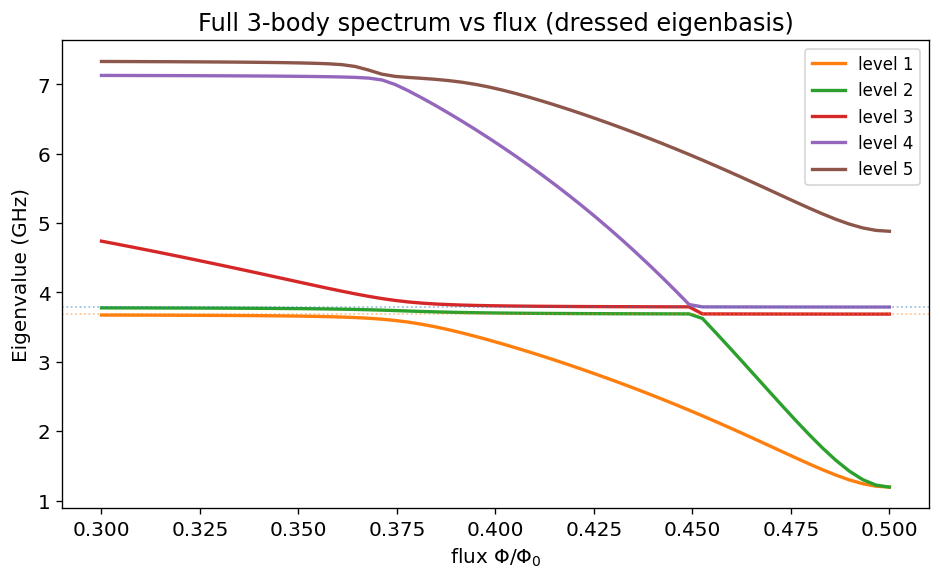

In [15]:
flux_coarse = np.linspace(0.3, 0.5, 60)  # stop before coupler diverges at 0.5
spec = system.flux_sweep_spectrum(flux_coarse, num_levels=6)

fig, ax = plt.subplots(figsize=(8, 5))
for lvl in range(1, spec.shape[1]):
    ax.plot(flux_coarse, spec[:, lvl], color=f"C{lvl}", lw=2, label=f"level {lvl}")

ax.axhline(omega_A, ls=":", color="C0", alpha=0.5, lw=1)
ax.axhline(omega_B, ls=":", color="C1", alpha=0.5, lw=1)
ax.set_xlabel(r"flux $\Phi/\Phi_0$")
ax.set_ylabel("Eigenvalue (GHz)")
ax.set_title("Full 3-body spectrum vs flux (dressed eigenbasis)")
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()

---
## Summary

| Class | Hamiltonian / frames | Key methods / properties |
|---|---|---|
| `Transmon` | Charge-basis tridiagonal | `charge_dispersion_sweep`, `ej_ec_sweep` |
| `TransmonResonator` | **Lab**: full $H_t\otimes H_r + g\hat{n}(a+a^\dagger)$; **rotating-RWA**: JC time-independent; **rotating**: JC time-dependent list | `dispersive_shift`, `resonator_frequency_sweep`, `build_hamiltonian(frame=…, omega_d=…)`, `_jc_coupling()` |
| `TunableCouplerSystem` | 3-body dressed-eigenbasis | `effective_coupling`, `flux_sweep_spectrum` |